# Session 2 - From an Experiment to a Complete ML Product

## Property Finder Egypt: all property listings

In Session 1, we learned how a Data Scientist thinks when receiving one residential-buy dataset for the first time.

Today we continue the same project. We will work with **all_egypt.csv**, compare stronger models, evaluate them honestly across different market segments, save the final model, and connect it to two Streamlit applications.

This is still a teaching notebook. The code is written naturally so we can reason through it together.

## What will we finish today?

By the end of this session, we will have:

1. Defined a defensible prediction problem across residential and commercial listings.
2. Built a clearer data-quality and feature-engineering process.
3. Compared Dummy, Ridge, Random Forest, HistGradientBoosting, XGBoost, and CatBoost.
4. Evaluated the models overall **and separately by market segment**.
5. Selected the strongest model from evidence, retrained it, and saved it.
6. Prepared a basic and an advanced Streamlit application.

The goal is not to chase a perfect score. The goal is to finish a complete project and understand every important decision.

## 1. Business Understanding

### What does “use all Egypt data” actually mean?

The file contains several markets. A residential apartment for monthly rent and a commercial building for sale do not have the same price meaning.

Before training anything, we need to discover which markets are present and decide what a single prediction should represent.

### Which standard Python tools will we need?

We will import tools in small groups. Each group has one purpose, so engineers can verify why it is needed.

In [ ]:
from pathlib import Path
import ast
import json
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Loading the Dataset

### Where is the data, and can the notebook find it from different launch folders?

Users may launch Jupyter from the project folder or its parent. We will check two sensible relative locations instead of hard-coding one computer's absolute path.

In [ ]:
df = pd.read_csv("DATA\\processed\\all_egypt.csv")

df.shape

(64106, 23)

### What should we conclude?

The supplied file contains **64,106 rows and 23 columns**. Setting `id` to string protects identifiers from accidental numeric conversion. We now know the file loaded correctly before doing any analysis.

## 3. What Did We Actually Receive?

### Do these rows look like one clean modeling table?

A small sample helps us connect column names to real listings. We are looking for the target, useful property characteristics, text fields, identifiers, and scraping metadata.

In [ ]:
df.head(3)

,id,title,price,currency,price_period,price_type,price_raw_value,property_type,location,latitude,longitude,images,share_url,bedrooms,bathrooms,size,amenities,category,page,scraped_at_utc,record_type,min_price,max_price
0,52974566,Luxurious Living in the Heart of Hyde Park!,"50,000.00",EGP,monthly,rent_price,"50,000.00",Apartment,"Hyde Park, New Cairo City, Cairo",30.00,31.55,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/rent/apar...,3.00,3.00,189.00,"['BA', 'SE', 'WC', 'LB']",rent,1,2026-02-19T16:31:09.727088+00:00,property,NaN,NaN
1,8653638,Apartment for Rent in Al Marasem Compound,"35,000.00",EGP,monthly,rent_price,"35,000.00",Apartment,"Moon Residences, Fifth Square, The 5th Settlem...",30.05,31.54,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/rent/apar...,3.00,2.00,170.00,"['BA', 'BW', 'AC', 'BK', 'CP']",rent,1,2026-02-19T16:31:09.727088+00:00,property,NaN,NaN
2,52974180,Flat Ultra Super Lux First Use For Rent-Villette,"70,000.00",EGP,monthly,rent_price,"70,000.00",Apartment,"Villette, 5th Settlement Compounds, The 5th Se...",30.02,31.55,['https://static.shared.propertyfinder.eg/medi...,https://www.propertyfinder.eg/en/plp/rent/apar...,3.00,3.00,161.00,"['BA', 'AC', 'CP', 'BK', 'SE', 'WC', 'BL', 'LB']",rent,1,2026-02-19T16:31:09.727088+00:00,property,NaN,NaN


### What should we conclude?

Each property row includes an asking price, property details, a hierarchical location, coordinates, amenities, images, and scrape metadata. Some columns look immediately useful; others may be identifiers, raw text, or possible leakage.

### Which columns and data types did we receive?

Data types tell us what Pandas understood automatically. They also reveal where “numbers” may still be text and where missing values forced integer-like columns to become floats.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64106 entries, 0 to 64105
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               64106 non-null  object 
 1   title            64106 non-null  object 
 2   price            62977 non-null  float64
 3   currency         62985 non-null  object 
 4   price_period     62985 non-null  object 
 5   price_type       62985 non-null  object 
 6   price_raw_value  62985 non-null  float64
 7   property_type    62985 non-null  object 
 8   location         62985 non-null  object 
 9   latitude         64106 non-null  float64
 10  longitude        64106 non-null  float64
 11  images           64106 non-null  object 
 12  share_url        62985 non-null  object 
 13  bedrooms         52593 non-null  float64
 14  bathrooms        60228 non-null  float64
 15  size             62985 non-null  float64
 16  amenities        62985 non-null  object 
 17  category    

### What should we conclude?

Bedrooms and bathrooms are floats because they contain missing values. Several important fields are text. `min_price` and `max_price` need investigation because their non-null counts are zero.

### What are the possible market segments?

`category`, `price_period`, and `record_type` describe what each row means. We should inspect them together before deciding on a target.

In [ ]:
segment_overview = (
    df.groupby(["record_type", "category", "price_period"], dropna=False)
      .size()
      .reset_index(name="rows")
      .sort_values("rows", ascending=False)
)

segment_overview

,record_type,category,price_period,rows
4,property,rent,monthly,19979
1,property,buy,sell,19967
3,property,commercial_rent,monthly,14080
2,property,commercial_buy,sell,8959
0,project,new_projects,NaN,1121


### What should we conclude?

The file mixes four property-listing markets:

- residential buy;
- residential rent;
- commercial buy;
- commercial rent.

It also contains project-summary rows. For buy categories, price means a sale asking price. For rent categories, it means a monthly asking price. We can build one educational global model only if `category` is included and every segment is evaluated separately.

### Are the target scales comparable across segments?

If one segment has prices thousands of times larger than another, an overall RMSE may mostly describe the expensive segment.

In [ ]:
target_by_category = (
    df.loc[df["record_type"].eq("property")]
      .groupby("category")["price"]
      .agg(rows="count", median="median", mean="mean", minimum="min", maximum="max")
      .sort_values("median")
)

target_by_category

,rows,median,mean,minimum,maximum
category,,,,,
rent,19979,"65,000.00","187,544.98","1,300.00","550,000,000.00"
commercial_rent,14080,"120,950.00","444,250.86","1,000.00","350,000,000.00"
buy,19965,"10,000,000.00","15,929,498.46","200,000.00","1,000,000,000.00"
commercial_buy,8953,"10,700,000.00","34,666,714.41","100,000.00","1,000,000,000.00"


### What should we conclude?

Monthly rent and sale prices live on very different scales. This leads to two modeling decisions:

1. Predict `log(1 + price)` so extreme values have less influence during training.
2. Convert predictions back to EGP and report results for each category, not only one global score.

## 4. Can We Trust This Combined Dataset?

### Where is information missing?

Missing values are not automatically errors. We need to discover whether they come from incomplete scraping, project rows, or features that do not apply to commercial properties.

In [ ]:
missing_audit = pd.DataFrame({
    "missing_rows": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
}).sort_values("missing_percent", ascending=False)

missing_audit

,missing_rows,missing_percent
max_price,64106,100.00
min_price,64106,100.00
bedrooms,11513,17.96
bathrooms,3878,6.05
price,1129,1.76
size,1121,1.75
share_url,1121,1.75
location,1121,1.75
property_type,1121,1.75
price_raw_value,1121,1.75


### What should we conclude?

`min_price` and `max_price` are completely empty and should not be model features. The same 1,121 project rows are missing many property-level fields. Bedrooms are often missing in commercial listings because the concept may not apply; that missingness may itself be informative.

### Are rows duplicated, and are identifiers unique?

Exact duplicates can make the model see the same evidence twice. Repeated IDs would suggest that one listing appears more than once.

In [ ]:
pd.Series({
    "exact_duplicate_rows": df.duplicated().sum(),
    "duplicated_ids": df["id"].duplicated().sum(),
    "unique_ids": df["id"].nunique(),
})

exact_duplicate_rows        0
duplicated_ids              0
unique_ids              64106
dtype: int64

### What should we conclude?

The supplied release has no exact duplicate rows and IDs are unique. We still perform this audit because a future scrape may behave differently. A check that returns zero is useful evidence, not wasted work.

### Are project rows suitable for property-level prediction?

Before dropping anything, compare record types. We want evidence that project summaries are genuinely a different unit of analysis.

In [ ]:
project_audit = df.groupby("record_type").agg(
    rows=("id", "size"),
    prices_present=("price", "count"),
    sizes_present=("size", "count"),
    locations_present=("location", "count"),
    property_types_present=("property_type", "count"),
)

project_audit

,rows,prices_present,sizes_present,locations_present,property_types_present
record_type,,,,,
project,1121,0,0,0,0
property,62985,62977,62985,62985,62985


### What should we conclude?

Project rows do not represent individual properties and do not contain the predictors needed by our app. We will keep them in the original dataset for auditing, but exclude them from this property-level model. This is a business-definition decision, not routine cleaning.

### Are there suspicious target or size values?

Real estate data is naturally skewed, so “large” does not always mean “wrong.” We will inspect extreme values before choosing broad, conservative guardrails.

In [ ]:
property_rows = df.loc[df["record_type"].eq("property")].copy()

property_rows[["price", "size"]].describe(
    percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
)

,price,size
count,"62,977.00","62,985.00"
mean,"10,137,122.19",462.14
std,"41,062,576.40","14,600.59"
min,"1,000.00",1.00
0.1%,"1,000.00",1.00
1%,"1,200.00",20.00
5%,"21,000.00",38.00
50%,"485,000.00",167.00
95%,"35,446,818.40",800.00
99%,"116,848,000.00","3,700.00"


### What should we conclude?

Both price and size have long right tails. We should not delete every luxury or large commercial listing. We will remove only missing/non-positive targets and property sizes below 10 m² or above 100,000 m², then use a log target to reduce the influence of the remaining extremes.

### What do the most suspicious size rows look like?

Looking at actual records prevents us from choosing a threshold only because a boxplot told us to.

In [ ]:
suspicious_size_rows = property_rows.loc[
    ~property_rows["size"].between(10, 100_000)
]

suspicious_size_rows[
    ["category", "property_type", "location", "size", "price"]
].sort_values("size").head(12)

,category,property_type,location,size,price
54059,commercial_buy,Retail,"City Walk Strip, Waslet Dahshur Road, Sheikh Z...",1.00,"4,500,000.00"
55211,commercial_buy,Clinic,"Six West, Beverly Hills, Sheikh Zayed Compound...",1.00,"2,500,000.00"
55207,commercial_buy,Office Space,"Skywalk Egypt Business Park, Cairo Alexandria ...",1.00,"4,000,000.00"
55195,commercial_buy,Retail,"1O1 Mall, Sheikh Zayed City, Giza",1.00,"3,500,000.00"
55174,commercial_buy,Whole Building,"District 5, 5th Settlement Compounds, The 5th ...",1.00,"17,148,300.00"
57042,commercial_buy,Show Room,"Sheikh Zayed Compounds, Sheikh Zayed City, Giza",1.00,"7,000,000.00"
55155,commercial_buy,Office Space,"Mazarine, New Alamein City, Al Alamein, North ...",1.00,"572,500.00"
55066,commercial_buy,Office Space,"Skyramp, Sheikh Zayed City, Giza",1.00,"4,000,000.00"
55060,commercial_buy,Office Space,"Arkan Palm 205, Sheikh Zayed Compounds, Sheikh...",1.00,"3,000,000.00"
55052,commercial_buy,Retail,"THRU, Waslet Dahshur Road, Sheikh Zayed City, ...",1.00,"7,000,000.00"


### What should we conclude?

Very small and extremely large values are likely incomplete entries, unit problems, or scraping mistakes. The broad threshold protects the model from obvious errors while preserving unusual but plausible properties.

### Can we trust the coordinates?

Latitude and longitude can be powerful location features, but zero or out-of-country coordinates should not be treated as real places.

In [ ]:
valid_egypt_coordinates = (
    property_rows["latitude"].between(22, 32.5)
    & property_rows["longitude"].between(24, 37)
)

pd.Series({
    "valid_coordinate_rows": valid_egypt_coordinates.sum(),
    "invalid_coordinate_rows": (~valid_egypt_coordinates).sum(),
})

valid_coordinate_rows      62900
invalid_coordinate_rows       85
dtype: int64

### What should we conclude?

Most coordinates are plausible, but invalid values exist. We will convert invalid coordinates to missing and create a flag. This keeps the listing without pretending `(0, 0)` is a meaningful Egyptian location.

## 5. Focused EDA for the Modeling Decision

### How different are segment price distributions?

We use a log x-axis because sale and rent prices cannot be read together on a normal scale.

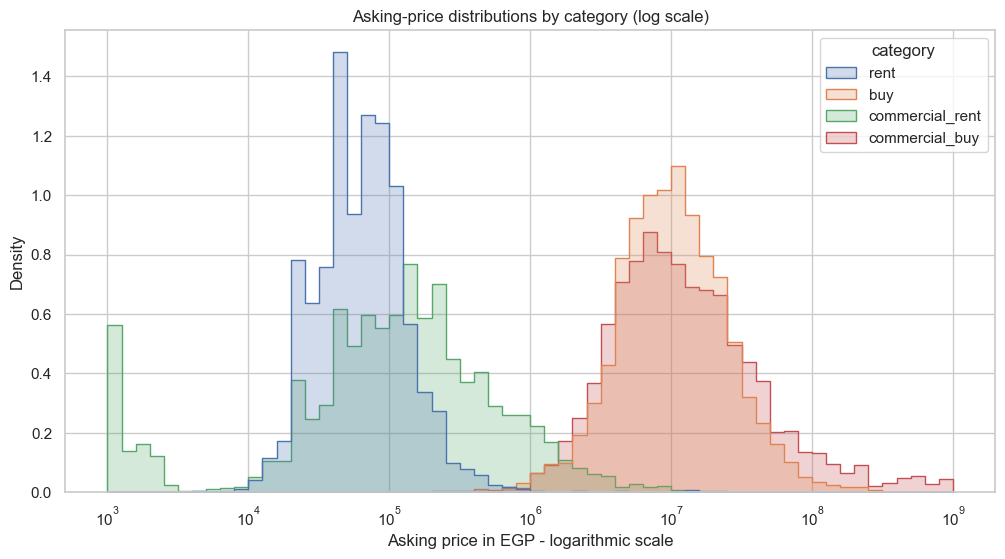

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=property_rows.dropna(subset=["price"]),
    x="price",
    hue="category",
    element="step",
    stat="density",
    common_norm=False,
    bins=60,
    log_scale=True,
)
plt.title("Asking-price distributions by category (log scale)")
plt.xlabel("Asking price in EGP - logarithmic scale")
plt.show()

### What should we conclude?

The categories overlap somewhat, but they are clearly different markets. `category` is essential, and a log target is not just a modeling trick—it matches the shape of the business data.

### Does size relate to price in every segment?

Size should matter, but the relationship may differ between rent, sale, residential, and commercial properties.

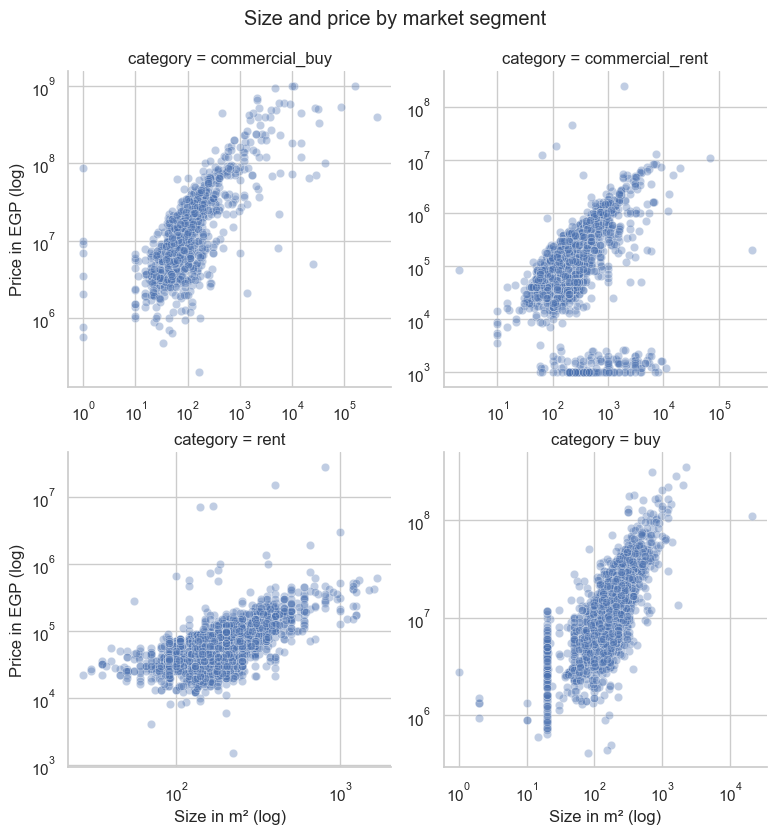

In [ ]:
valid_plot_rows = property_rows.dropna(
    subset=["price", "size"]
)

plot_sample = valid_plot_rows.sample(
    n=min(8_000, len(valid_plot_rows)),
    random_state=RANDOM_STATE,
)

g = sns.relplot(
    data=plot_sample,
    x="size",
    y="price",
    col="category",
    col_wrap=2,
    alpha=0.35,
    height=4,
    facet_kws={"sharex": False, "sharey": False},
)

g.set(xscale="log", yscale="log")
g.set_axis_labels("Size in m² (log)", "Price in EGP (log)")
g.fig.suptitle("Size and price by market segment", y=1.03)
plt.show()

### What should we conclude?

Larger properties generally cost more, but size alone cannot explain price. The different clouds suggest interactions with category, property type, and location—exactly the kind of non-linearity tree-based boosting models can learn.

### Which property types dominate each category?

The same property-type label may behave differently across residential and commercial markets.

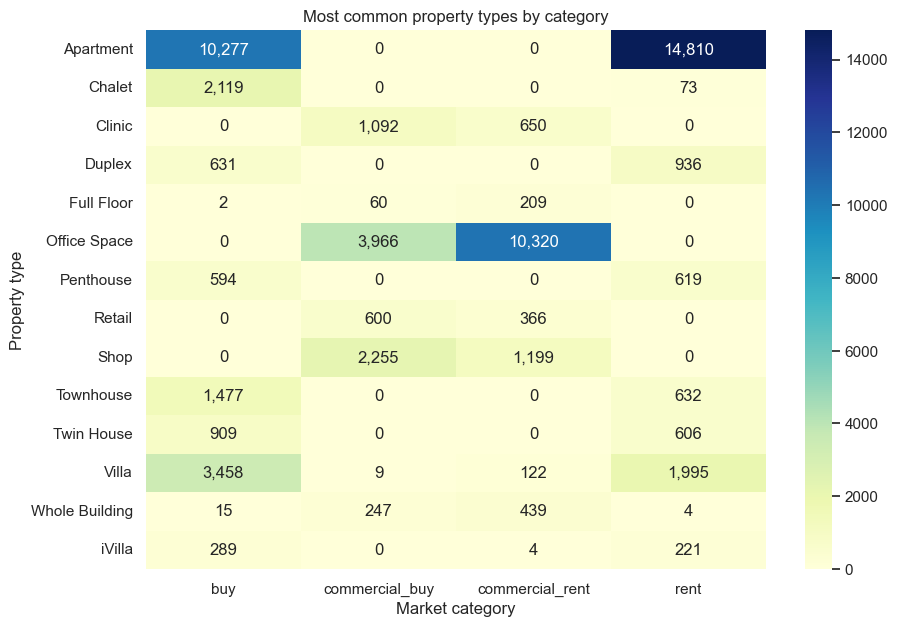

In [ ]:
top_property_types = (
    property_rows["property_type"]
    .value_counts()
    .head(14)
    .index
)

common_type_rows = property_rows[
    property_rows["property_type"].isin(top_property_types)
]

property_type_matrix = pd.crosstab(
    common_type_rows["property_type"],
    common_type_rows["category"],
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    property_type_matrix,
    annot=True,
    fmt=",",
    cmap="YlGnBu",
)
plt.title("Most common property types by category")
plt.xlabel("Market category")
plt.ylabel("Property type")
plt.show()

### What should we conclude?

Apartments and villas dominate residential categories, while offices, retail, warehouses, and other types appear in commercial categories. A model needs both `category` and `property_type` to interpret the same numeric features correctly.

## 6. Cleaning - What Evidence Justifies Each Decision?

### How many rows does each cleaning decision remove?

A cleaning log makes the cost of every decision visible. Quietly deleting rows is a dangerous habit.

In [ ]:
modeling_df = df[df["record_type"].eq("property")].copy()

cleaning_log = [
    {"decision": "Received all rows", "rows_remaining": len(df)},
    {"decision": "Keep property-level rows", "rows_remaining": len(modeling_df)},
]

valid_target = (
    modeling_df["price"].notna()
    & modeling_df["price"].gt(0)
)

modeling_df = modeling_df[valid_target].copy()
cleaning_log.append({
    "decision": "Keep valid positive targets",
    "rows_remaining": len(modeling_df),
})

A regression target must be present and positive. This rule removed only rows the model cannot learn from.

Which size values pass our conservative guardrail?

In [ ]:
valid_size = modeling_df["size"].between(20, 100_000)

modeling_df = modeling_df[valid_size].copy()
cleaning_log.append({
    "decision": "Keep plausible sizes",
    "rows_remaining": len(modeling_df),
})

cleaning_log = pd.DataFrame(cleaning_log)

cleaning_log["rows_removed_since_previous"] = (
    cleaning_log["rows_remaining"].shift(1)
    - cleaning_log["rows_remaining"]
).fillna(0).astype(int)

cleaning_log

,decision,rows_remaining,rows_removed_since_previous
0,Received all rows,64106,0
1,Keep property-level rows,62985,1121
2,Keep valid positive targets,62977,8
3,Keep plausible sizes,62494,483


### What should we conclude?

We retain the great majority of real property rows. The largest exclusion is the separate project-summary record type, not an arbitrary outlier rule. The final modeling population still covers all four listing categories across Egypt.

### Should missing bedrooms and bathrooms be deleted?

In commercial real estate, a missing bedroom count often means “not applicable,” not “bad row.” Let us check missingness by segment.

In [ ]:
room_missingness = (
    modeling_df.groupby("category")[["bedrooms", "bathrooms"]]
    .apply(lambda group: group.isna().mean().mul(100))
)

room_missingness

,bedrooms,bathrooms
category,,
buy,2.84,0.15
commercial_buy,53.47,16.84
commercial_rent,29.93,8.20
rent,3.50,0.00


### What should we conclude?

Missing room values are concentrated in commercial categories. We will keep these rows, create missingness flags, and allow the preprocessing/model to handle the missing numeric values. Deleting them would remove useful commercial evidence.

### How should invalid coordinates be handled?

We will keep the property, flag the coordinate problem, and replace the invalid values with `NaN`. Later, classical pipelines will impute them and CatBoost will handle missing numeric values directly.

In [ ]:
valid_egypt_coordinates = (
    modeling_df["latitude"].between(22, 32.5)
    & modeling_df["longitude"].between(24, 37)
)

modeling_df["coordinate_missing"] = (~valid_egypt_coordinates).astype(int)
modeling_df.loc[~valid_egypt_coordinates, ["latitude", "longitude"]] = np.nan

modeling_df[["latitude", "longitude", "coordinate_missing"]].head()

,latitude,longitude,coordinate_missing
0,30.00,31.55,0
1,30.05,31.54,0
2,30.02,31.55,0
3,30.02,31.51,0
4,30.00,31.55,0


### What should we conclude?

The coordinate flag tells the model that an imputed coordinate is not the same as an observed coordinate. This is a simple test setple of preserving the meaning of missingness.

## 7. Feature Engineering - What New Information Can We Give the Model?

### Can raw amenity and image lists become useful numeric features?

The model does not need the full Python-list text. Counts can represent how richly a listing is described and how many facilities are advertised.

In [ ]:
amenities_as_lists = (
    modeling_df["amenities"]
    .fillna("[]")
    .apply(ast.literal_eval)
)

modeling_df["amenities_count"] = amenities_as_lists.str.len()

modeling_df["images_count"] = (
    modeling_df["images"]
    .fillna("")
    .str.count("https://")
)

modeling_df[
    ["amenities", "amenities_count", "images_count"]
].head()

,amenities,amenities_count,images_count
0,"['BA', 'SE', 'WC', 'LB']",4,2
1,"['BA', 'BW', 'AC', 'BK', 'CP']",5,2
2,"['BA', 'AC', 'CP', 'BK', 'SE', 'WC', 'BL', 'LB']",8,2
3,"['BA', 'BW', 'AC', 'CP', 'BK', 'SP', 'SE', 'SY...",11,2
4,"['BA', 'BW', 'AC', 'CP', 'BK', 'CO', 'LB', 'BL...",11,2


### What should we conclude?

`amenities_count` and `images_count` compress long text into simple, deployable signals. They do not tell us which amenity is present, but they give the model useful listing-completeness information without complicated text processing.

### What can we safely learn from Property Finder's location breadcrumb?

The CSV contains one comma-separated `location` string. It does **not** contain verified district, city, and governorate columns.

We can derive useful marketplace levels, but we must name them honestly and keep the original location string.

In [ ]:
location_parts = (
    modeling_df["location"]
    .fillna("Unknown")
    .str.split(",")
)

location_depth = location_parts.str.len()
location_depth.value_counts().sort_index()

location
2     1114
3    10643
4    27048
5    23689
Name: count, dtype: int64

No. Property Finder locations contain two to five levels. A position can therefore represent a compound, street, neighborhood, or district.

What neutral name can we use for the broadest marketplace label?

In [ ]:
modeling_df["market_region"] = (
    location_parts.str[-1].str.strip()
)

modeling_df["market_city"] = (
    location_parts.str[-2]
    .str.strip()
    .fillna("Unknown")
)

modeling_df["local_area"] = (
    location_parts.str[-3]
    .str.strip()
    .fillna("Unknown")
)

modeling_df[
    ["location", "local_area", "market_city", "market_region"]
].head(8)

,location,local_area,market_city,market_region
0,"Hyde Park, New Cairo City, Cairo",Hyde Park,New Cairo City,Cairo
1,"Moon Residences, Fifth Square, The 5th Settlem...",The 5th Settlement,New Cairo City,Cairo
2,"Villette, 5th Settlement Compounds, The 5th Se...",The 5th Settlement,New Cairo City,Cairo
3,"South Lotus, El Lotus, New Cairo City, Cairo",El Lotus,New Cairo City,Cairo
4,"Hyde Park, New Cairo City, Cairo",Hyde Park,New Cairo City,Cairo
5,"Cairo Festival City, North Investors Area, New...",North Investors Area,New Cairo City,Cairo
6,"The Address, 12th District, Sheikh Zayed City,...",12th District,Sheikh Zayed City,Giza
7,"Villette, 5th Settlement Compounds, The 5th Se...",The 5th Settlement,New Cairo City,Cairo


### What should we conclude?

The parsed levels are useful model features, but they are not official administrative truth. `Hyde Park` may be a development, `12th District` may be a district, and `North Coast` is a market region.

If a real product needs official boundaries, we would validate coordinates against a trusted geographic reference or perform a spatial join.

### Can rooms and size express more than their raw values?

Total rooms, missingness flags, and log size can help models represent scale and “not applicable” room information more clearly.

In [ ]:
modeling_df["bedroom_missing"] = (
    modeling_df["bedrooms"].isna().astype(int)
)

modeling_df["bathroom_missing"] = (
    modeling_df["bathrooms"].isna().astype(int)
)

room_columns = ["bedrooms", "bathrooms"]

modeling_df["total_rooms"] = (
    modeling_df[room_columns]
    .fillna(0)
    .sum(axis=1)
)

modeling_df["log_size"] = np.log1p(modeling_df["size"])

engineered_columns = [
    "bedrooms", "bathrooms", "total_rooms",
    "bedroom_missing", "bathroom_missing",
    "size", "log_size",
]

modeling_df[engineered_columns].head()

,bedrooms,bathrooms,total_rooms,bedroom_missing,bathroom_missing,size,log_size
0,3.00,3.00,6.00,0,0,189.00,5.25
1,3.00,2.00,5.00,0,0,170.00,5.14
2,3.00,3.00,6.00,0,0,161.00,5.09
3,1.00,1.00,2.00,0,0,80.00,4.39
4,1.00,1.00,2.00,0,0,80.00,4.39


### What should we conclude?

These features give the model both the original values and useful summaries. `log_size` reduces the huge gap between a small apartment and a very large commercial property without discarding either one.

### Should price per square meter be a model feature?

It is valuable for analysis because it normalizes price by size. But it uses the target price, so including it in the model would reveal the answer.

In [ ]:
modeling_df["price_per_sqm_analysis_only"] = (
    modeling_df["price"] / modeling_df["size"]
)

modeling_df.groupby("category")["price_per_sqm_analysis_only"].median().sort_values()

category
rent                  347.83
commercial_rent       900.00
buy                68,888.89
commercial_buy    133,333.33
Name: price_per_sqm_analysis_only, dtype: float64

### What should we conclude?

Price per square meter is useful for understanding markets and checking predictions, but it is **target leakage** for prediction. It will not appear in `feature_columns`.

## 8. Feature Selection

### Which columns should the model use—and which should it never see?

We want features available when a user asks for a new prediction. Identifiers, URLs, raw target copies, and scrape metadata either cannot generalize or leak the answer.

In [ ]:
numeric_features = [
    "bedrooms",
    "bathrooms",
    "size",
    "latitude",
    "longitude",
    "amenities_count",
    "images_count",
    "total_rooms",
    "log_size",
    "bedroom_missing",
    "bathroom_missing",
    "coordinate_missing",
]

categorical_features = [
    "category",
    "price_period",
    "property_type",
    "market_region",
    "market_city",
    "local_area",
    "location",
]

feature_columns = numeric_features + categorical_features

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features: {len(feature_columns)}")

Numeric features: 12
Categorical features: 7
Total features: 19


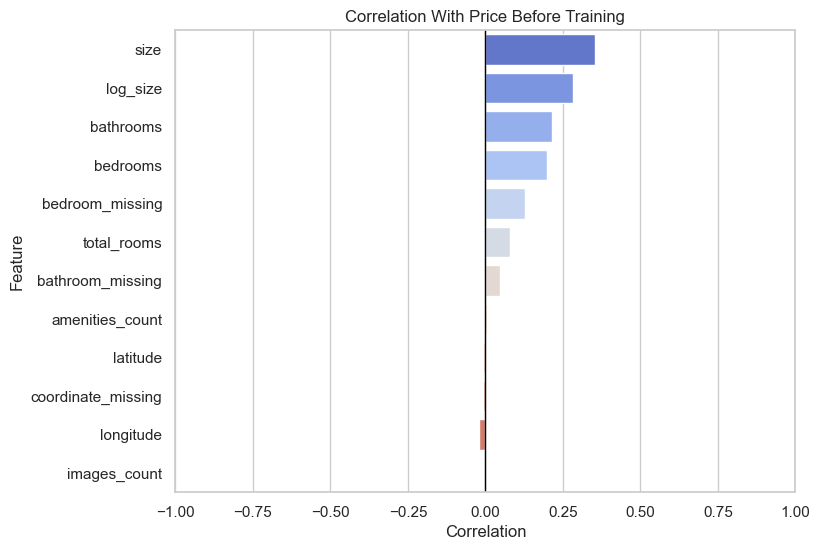

In [ ]:
price_correlation = (
    modeling_df[numeric_features + ["price"]]
    .corr(numeric_only=True)["price"]
    .drop("price")
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
sns.barplot(
    x=price_correlation.values,
    y=price_correlation.index,
    palette="coolwarm"
)

plt.title("Correlation With Price Before Training")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.xlim(-1, 1)
plt.axvline(0, color="black", linewidth=1)
plt.show()

The model will receive 19 columns. Now we must document what it will **not** receive.

In [ ]:
excluded_columns = {
    "id": "identifier",
    "share_url": "identifier / URL",
    "title": "free text not requested by the app",
    "price": "target",
    "price_raw_value": "direct target leakage",
    "price_type": "redundant",
    "currency": "constant in this dataset",
    "amenities": "replaced by amenities_count",
    "images": "replaced by images_count",
    "page": "scraping metadata",
    "scraped_at_utc": "scraping metadata",
    "record_type": "constant after filtering",
    "min_price": "completely missing",
    "max_price": "completely missing",
    "price_per_sqm_analysis_only": "target leakage",
}

exclusion_table = pd.DataFrame(
    excluded_columns.items(),
    columns=["excluded_column", "reason"],
)

exclusion_table

,excluded_column,reason
0,id,identifier
1,share_url,identifier / URL
2,title,free text not requested by the app
3,price,target
4,price_raw_value,direct target leakage
5,price_type,redundant
6,currency,constant in this dataset
7,amenities,replaced by amenities_count
8,images,replaced by images_count
9,page,scraping metadata


### What should we conclude?

Feature selection is not “keep whatever is numeric.” It is a prediction-time availability test. Every chosen input can be collected in the Streamlit app without already knowing the target.

### Are the final features ready for modeling?

CatBoost requires categorical values to be strings. We will fill missing labels with `Unknown` while leaving missing numeric values for each model's appropriate handling strategy.

In [ ]:
for column in categorical_features:
    modeling_df[column] = modeling_df[column].fillna("Unknown").astype(str)

modeling_df[feature_columns + ["price"]].head()

,bedrooms,bathrooms,size,latitude,longitude,amenities_count,images_count,total_rooms,log_size,bedroom_missing,bathroom_missing,coordinate_missing,category,price_period,property_type,market_region,market_city,local_area,location,price
0,3.00,3.00,189.00,30.00,31.55,4,2,6.00,5.25,0,0,0,rent,monthly,Apartment,Cairo,New Cairo City,Hyde Park,"Hyde Park, New Cairo City, Cairo","50,000.00"
1,3.00,2.00,170.00,30.05,31.54,5,2,5.00,5.14,0,0,0,rent,monthly,Apartment,Cairo,New Cairo City,The 5th Settlement,"Moon Residences, Fifth Square, The 5th Settlem...","35,000.00"
2,3.00,3.00,161.00,30.02,31.55,8,2,6.00,5.09,0,0,0,rent,monthly,Apartment,Cairo,New Cairo City,The 5th Settlement,"Villette, 5th Settlement Compounds, The 5th Se...","70,000.00"
3,1.00,1.00,80.00,30.02,31.51,11,2,2.00,4.39,0,0,0,rent,monthly,Apartment,Cairo,New Cairo City,El Lotus,"South Lotus, El Lotus, New Cairo City, Cairo","22,000.00"
4,1.00,1.00,80.00,30.00,31.55,11,2,2.00,4.39,0,0,0,rent,monthly,Apartment,Cairo,New Cairo City,Hyde Park,"Hyde Park, New Cairo City, Cairo","35,000.00"


### What should we conclude?

The modeling table now has a clear contract: 12 numeric features, 7 categorical features, and one target. The full location remains high-cardinality, which will test whether CatBoost's native categorical handling is valuable.

## 9. Train/Test Split

### How can we simulate unseen listings without losing a market segment?

The test set is like unseen test evaluations. We stratify by category so each of the four markets appears in both training and testing.

In [ ]:
X = modeling_df[feature_columns].copy()
y_price = modeling_df["price"].copy()

X_train, X_test, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=modeling_df["category"],
)

y_train_log = np.log1p(y_train_price)
y_test_log = np.log1p(y_test_price)

split_summary = pd.DataFrame({
    "training_rows": [len(X_train)],
    "testing_rows": [len(X_test)],
    "training_share": [len(X_train) / len(X)],
})

split_summary

,training_rows,testing_rows,training_share
0,49995,12499,0.80


### What should we conclude?

The test rows will not be used to fit the models. We train on log price but keep the original EGP target so evaluation remains understandable to the business.

### Did stratification preserve the four markets?

We verify the split rather than assuming the function did what we intended.

In [ ]:
split_balance = pd.concat(
    [
        X_train["category"].value_counts(normalize=True).rename("train_share"),
        X_test["category"].value_counts(normalize=True).rename("test_share"),
    ],
    axis=1,
)

split_balance

,train_share,test_share
category,,
rent,0.32,0.32
buy,0.32,0.32
commercial_rent,0.22,0.22
commercial_buy,0.14,0.14


### What should we conclude?

Train and test contain almost identical category proportions. A weak result in one segment cannot be blamed on that segment disappearing from the test set.

## 10. Preprocessing Pipelines

### Why do classical models need a pipeline?

Ridge, Random Forest, HistGradientBoosting, and XGBoost cannot directly interpret text categories. A pipeline learns missing-value handling and encoding from the training set, then applies the same rules to the test set and future app inputs.

In [ ]:
numeric_linear_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_linear_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=20,
    )),
])

linear_preprocessor = ColumnTransformer([
    ("numbers", numeric_linear_steps, numeric_features),
    ("categories", categorical_linear_steps, categorical_features),
])

The column transformer sends each column group through the correct preparation steps.

How will classical tree models receive categories?

In [ ]:
categorical_tree_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )),
])

tree_preprocessor = ColumnTransformer([
    ("numbers", SimpleImputer(strategy="median"), numeric_features),
    ("categories", categorical_tree_steps, categorical_features),
])

### What should we conclude?

Ridge uses one-hot encoding and scaling because distances and coefficient sizes matter. Tree models use compact ordinal codes because they do not require scaled inputs. Unknown future labels receive safe behavior instead of crashing the app.

## 11. Baseline and Candidate Models

### What is the simplest prediction we must beat?

The Dummy Regressor predicts the training median log price for every row. If a complex model cannot beat this, the extra complexity has not earned its place.

In [ ]:
model_results = []
prediction_store = {}

dummy_model = DummyRegressor(strategy="median")

dummy_train_input = np.zeros((len(X_train), 1))
dummy_model.fit(dummy_train_input, y_train_log)

dummy_test_input = np.zeros((len(X_test), 1))
dummy_predictions_log = dummy_model.predict(dummy_test_input)
dummy_predictions = np.expm1(dummy_predictions_log)

prediction_store["Dummy"] = dummy_predictions

dummy_result = {
    "model": "Dummy",
    "MAE": mean_absolute_error(y_test_price, dummy_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_price, dummy_predictions)),
    "R2": r2_score(y_test_price, dummy_predictions),
}

model_results.append(dummy_result)
pd.DataFrame([dummy_result])

,model,MAE,RMSE,R2
0,Dummy,"9,820,570.75","41,046,583.31",-0.06


### What should we conclude?

The dummy result is intentionally weak. It gives every stronger model a meaningful reference point and reminds us that “the model ran” is not the same as “the model learned.”

### Can a regularized linear model find a stable relationship?

Ridge is a stronger version of Linear Regression for many encoded features. It remains interpretable as a linear relationship and gives us a useful classical benchmark.

In [ ]:
ridge_model = Pipeline([
    ("preprocessing", linear_preprocessor),
    ("model", Ridge(alpha=10.0)),
])

started = time.time()
ridge_model.fit(X_train, y_train_log)
ridge_seconds = time.time() - started

ridge_predictions_log = ridge_model.predict(X_test)
ridge_predictions = np.expm1(ridge_predictions_log)

prediction_store["Ridge"] = ridge_predictions

ridge_result = {
    "model": "Ridge",
    "MAE": mean_absolute_error(y_test_price, ridge_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_price, ridge_predictions)),
    "R2": r2_score(y_test_price, ridge_predictions),
    "training_seconds": ridge_seconds,
}

model_results.append(ridge_result)
pd.DataFrame([ridge_result])

,model,MAE,RMSE,R2,training_seconds
0,Ridge,"4,399,668.15","29,776,359.56",0.44,0.62


### What should we conclude?

Ridge should beat the dummy model because size, market category, type, and location carry genuine signal. Its limitation is that it combines them mostly through linear additive relationships.

### Can a Random Forest capture non-linear interactions?

Many trees can learn rules such as “size matters differently for offices in Cairo than for apartments in Giza.” We control depth and leaf size to keep training practical.

In [ ]:
random_forest_regressor = RandomForestRegressor(
    n_estimators=120,
    max_depth=18,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

random_forest_model = Pipeline([
    ("preprocessing", tree_preprocessor),
    ("model", random_forest_regressor),
])

started = time.time()
random_forest_model.fit(X_train, y_train_log)
random_forest_seconds = time.time() - started

The Random Forest is fitted. Let us create EGP predictions.

In [ ]:
random_forest_predictions_log = random_forest_model.predict(X_test)
random_forest_predictions = np.expm1(random_forest_predictions_log)

prediction_store["Random Forest"] = random_forest_predictions

random_forest_result = {
    "model": "Random Forest",
    "MAE": mean_absolute_error(y_test_price, random_forest_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_price, random_forest_predictions)),
    "R2": r2_score(y_test_price, random_forest_predictions),
    "training_seconds": random_forest_seconds,
}

model_results.append(random_forest_result)
pd.DataFrame([random_forest_result])

,model,MAE,RMSE,R2,training_seconds
0,Random Forest,"2,939,990.60","19,363,754.40",0.76,2.76


### What should we conclude?

Random Forest can model interactions without manually writing them. It is stronger than a single Decision Tree, but ordinal category codes are still an imperfect representation of text labels.

### Can gradient boosting improve one small mistake at a time?

HistGradientBoosting builds trees sequentially. Each new tree focuses on errors left by the earlier trees.

In [ ]:
hist_gradient_regressor = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_iter=220,
    max_leaf_nodes=31,
    l2_regularization=0.5,
    random_state=RANDOM_STATE,
)

hist_gradient_model = Pipeline([
    ("preprocessing", tree_preprocessor),
    ("model", hist_gradient_regressor),
])

started = time.time()
hist_gradient_model.fit(X_train, y_train_log)
hist_gradient_seconds = time.time() - started

The model is fitted. Let us create prices in EGP.

In [ ]:
hist_gradient_predictions_log = hist_gradient_model.predict(X_test)
hist_gradient_predictions = np.expm1(hist_gradient_predictions_log)

prediction_store["HistGradientBoosting"] = hist_gradient_predictions

hist_gradient_result = {
    "model": "HistGradientBoosting",
    "MAE": mean_absolute_error(y_test_price, hist_gradient_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_price, hist_gradient_predictions)),
    "R2": r2_score(y_test_price, hist_gradient_predictions),
    "training_seconds": hist_gradient_seconds,
}

model_results.append(hist_gradient_result)
pd.DataFrame([hist_gradient_result])

,model,MAE,RMSE,R2,training_seconds
0,HistGradientBoosting,"3,421,967.23","21,234,730.21",0.72,1.34


### What should we conclude?

Boosting often learns tabular patterns efficiently. We now have a stronger non-linear benchmark before moving to external boosting libraries.

### What does XGBoost add?

XGBoost is a widely used gradient-boosted tree library. We use sensible settings only—no hyperparameter search—because the workshop is about the workflow, not leaderboard optimization.

In [ ]:
xgboost_regressor = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

xgboost_model = Pipeline([
    ("preprocessing", tree_preprocessor),
    ("model", xgboost_regressor),
])

started = time.time()
xgboost_model.fit(X_train, y_train_log)
xgboost_seconds = time.time() - started

XGBoost is fitted. Let us convert its log predictions to EGP.

In [ ]:
xgboost_predictions_log = xgboost_model.predict(X_test)
xgboost_predictions = np.expm1(xgboost_predictions_log)

prediction_store["XGBoost"] = xgboost_predictions

xgboost_result = {
    "model": "XGBoost",
    "MAE": mean_absolute_error(y_test_price, xgboost_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_price, xgboost_predictions)),
    "R2": r2_score(y_test_price, xgboost_predictions),
    "training_seconds": xgboost_seconds,
}

model_results.append(xgboost_result)
pd.DataFrame([xgboost_result])

,model,MAE,RMSE,R2,training_seconds
0,XGBoost,"3,196,556.97","20,546,451.55",0.74,1.17


### What should we conclude?

XGBoost usually improves on simpler tree ensembles, but it still receives ordinal-encoded category labels. The next model can work with category names directly.

### Why is CatBoost especially interesting for this dataset?

CatBoost was designed to handle categorical features such as property type, market region, local area, and full location. It can learn from high-cardinality categories without creating thousands of one-hot columns.

In [ ]:
catboost_model = CatBoostRegressor(
    iterations=220,
    learning_rate=0.07,
    depth=7,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=50,
    allow_writing_files=False,
)

started = time.time()

catboost_model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_features,
)

catboost_seconds = time.time() - started

0:	learn: 2.5992778	total: 79.2ms	remaining: 17.3s
50:	learn: 0.7804629	total: 3.45s	remaining: 11.4s
100:	learn: 0.7318431	total: 6.75s	remaining: 7.95s
150:	learn: 0.7085995	total: 10.1s	remaining: 4.6s
200:	learn: 0.6922994	total: 13.4s	remaining: 1.26s
219:	learn: 0.6878461	total: 14.6s	remaining: 0us


CatBoost is fitted with the same training rows and target as every other candidate.

What prices does it predict?

In [ ]:
catboost_predictions_log = catboost_model.predict(X_test)
catboost_predictions = np.expm1(catboost_predictions_log)

prediction_store["CatBoost"] = catboost_predictions

catboost_result = {
    "model": "CatBoost",
    "MAE": mean_absolute_error(y_test_price, catboost_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_price, catboost_predictions)),
    "R2": r2_score(y_test_price, catboost_predictions),
    "training_seconds": catboost_seconds,
}

model_results.append(catboost_result)
pd.DataFrame([catboost_result])

,model,MAE,RMSE,R2,training_seconds
0,CatBoost,"3,414,851.49","20,667,960.67",0.73,14.98


### What should we conclude?

CatBoost preserves readable category labels and the full Property Finder location breadcrumb. Training takes longer, but the input contract remains understandable for deployment.

## 12. Overall Evaluation

### Which model looks strongest when all categories are mixed together?

We compare MAE, RMSE, and R² in original EGP. Lower MAE/RMSE is better; higher R² is better.

In [ ]:
model_results_df = (
    pd.DataFrame(model_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

model_results_df.style.format({
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "R2": "{:.3f}",
    "training_seconds": "{:.1f}",
})

,model,MAE,RMSE,R2,training_seconds
0,Random Forest,"2,939,991","19,363,754",0.765,2.8
1,XGBoost,"3,196,557","20,546,452",0.735,1.2
2,CatBoost,"3,414,851","20,667,961",0.732,15.0
3,HistGradientBoosting,"3,421,967","21,234,730",0.717,1.3
4,Ridge,"4,399,668","29,776,360",0.444,0.6
5,Dummy,"9,820,571","41,046,583",-0.056,nan


### What should we conclude?

The advanced tree-based models should clearly beat the dummy and linear baselines. However, the large sale prices dominate overall MAE, RMSE, and R². We cannot select a deployment model from this table alone.

### Can we compare model performance visually?

A bar chart makes the error gap easier to discuss, but remember that a lower global RMSE may still hide a weak rent model.

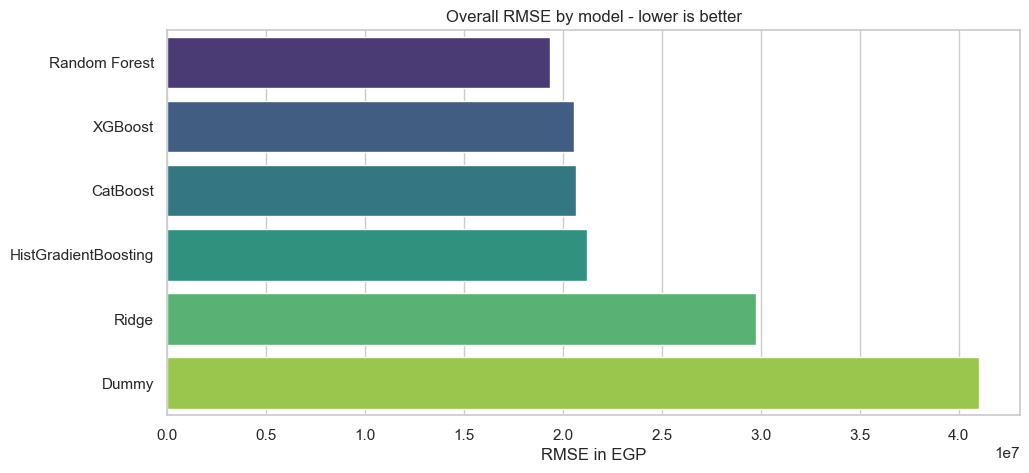

In [ ]:
plt.figure(figsize=(11, 5))
sns.barplot(data=model_results_df, x="RMSE", y="model", palette="viridis")
plt.title("Overall RMSE by model - lower is better")
plt.xlabel("RMSE in EGP")
plt.ylabel("")
plt.show()

### What should we conclude?

Visual comparison is useful for ranking, not for deciding business fitness. Because the target spans monthly rent and sale prices, the next table is more important.

## 13. Segment-Level Evaluation

### Does the chosen model work equally well in every market?

For each model and category, we calculate:

- MAE in EGP;
- RMSE in EGP;
- R²;
- median absolute percentage error (Median APE), which is easier to compare across price scales.

In [ ]:
prediction_frames = []

for model_name, predictions in prediction_store.items():
    current_predictions = pd.DataFrame({
        "model": model_name,
        "actual": y_test_price.to_numpy(),
        "predicted": predictions,
        "category": X_test["category"].to_numpy(),
    })
    prediction_frames.append(current_predictions)

all_predictions = pd.concat(prediction_frames, ignore_index=True)

segment_rows = []

for (model_name, category_name), group in all_predictions.groupby(
    ["model", "category"]
):
    percentage_error = (
        (group["actual"] - group["predicted"]).abs()
        / group["actual"]
    )

    segment_rows.append({
        "model": model_name,
        "category": category_name,
        "rows": len(group),
        "median_price": group["actual"].median(),
        "MAE": mean_absolute_error(group["actual"], group["predicted"]),
        "RMSE": np.sqrt(mean_squared_error(group["actual"], group["predicted"])),
        "R2": r2_score(group["actual"], group["predicted"]),
        "median_APE": percentage_error.median(),
    })

The loop applies exactly the same metric definitions to every model and every category.

What does the segment table show?

In [ ]:
segment_results = pd.DataFrame(segment_rows)

segment_results = segment_results.sort_values(
    ["category", "median_APE"]
)

segment_results.style.format({
    "median_price": "{:,.0f}",
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "R2": "{:.3f}",
    "median_APE": "{:.1%}",
})

,model,category,rows,median_price,MAE,RMSE,R2,median_APE
12,Random Forest,buy,3977,"10,000,000","4,262,844","18,526,074",0.563,16.3%
20,XGBoost,buy,3977,"10,000,000","4,539,932","18,139,921",0.581,19.7%
8,HistGradientBoosting,buy,3977,"10,000,000","4,849,157","18,864,142",0.547,21.1%
16,Ridge,buy,3977,"10,000,000","5,407,235","20,707,956",0.454,22.8%
0,CatBoost,buy,3977,"10,000,000","5,108,469","19,101,572",0.536,24.3%
4,Dummy,buy,3977,"10,000,000","15,627,580","32,094,065",-0.311,95.5%
13,Random Forest,commercial_buy,1725,"11,000,000","10,529,048","42,432,929",0.791,17.6%
21,XGBoost,commercial_buy,1725,"11,000,000","11,723,043","46,647,386",0.748,22.2%
9,HistGradientBoosting,commercial_buy,1725,"11,000,000","12,636,550","48,186,524",0.731,23.8%
1,CatBoost,commercial_buy,1725,"11,000,000","11,966,903","46,136,273",0.753,26.5%


### What should we conclude?

A model can have a strong overall R² while rent-segment R² remains weak. Median APE is often more stable here because a few exceptionally expensive listings do not dominate it. Honest evaluation means reporting both absolute business error and scale-aware segment error.

### Which model is most consistent across segments?

We plot Median APE as a heatmap. Darker/lower cells represent smaller typical proportional errors.

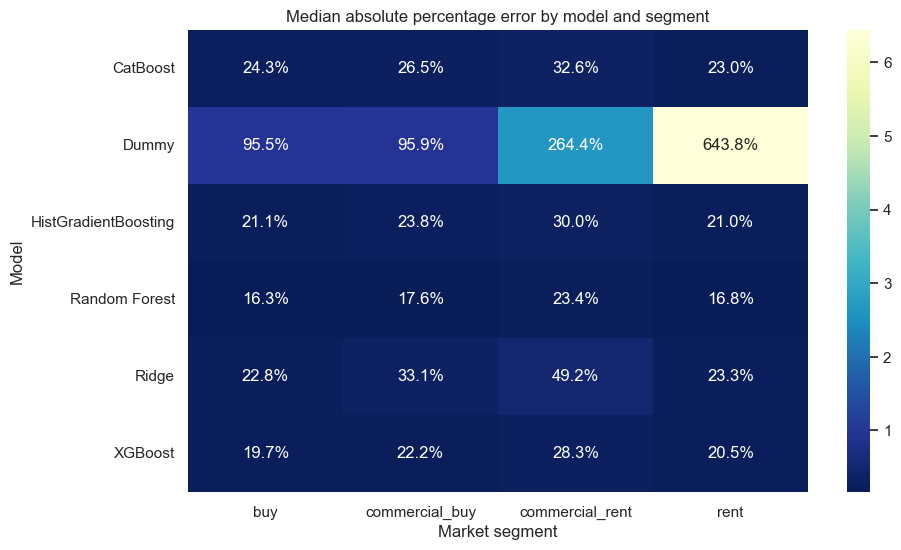

In [ ]:
segment_error_matrix = segment_results.pivot(
    index="model",
    columns="category",
    values="median_APE",
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    segment_error_matrix,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu_r",
)
plt.title("Median absolute percentage error by model and segment")
plt.xlabel("Market segment")
plt.ylabel("Model")
plt.show()

### What should we conclude?

The most useful final model is the one that combines strong overall results with reasonable error across all four categories. On this dataset and these untuned settings, **Random Forest wins the overall RMSE and the median percentage error in every segment**. CatBoost remains an important candidate, but model selection must follow evidence rather than reputation.

## 14. Error Analysis

### What do individual Random Forest predictions look like?

Aggregated metrics can hide failure modes. We inspect test setple predictions from each category, including absolute and percentage errors.

In [ ]:
test setple_columns = [
    "category",
    "property_type",
    "location",
    "size",
]

final_test setples = X_test[test setple_columns].copy()
final_test setples["actual_price"] = y_test_price.to_numpy()
final_test setples["predicted_price"] = random_forest_predictions

final_test setples["absolute_error"] = (
    final_test setples["actual_price"]
    - final_test setples["predicted_price"]
).abs()

final_test setples["absolute_percentage_error"] = (
    final_test setples["absolute_error"]
    / final_test setples["actual_price"]
)

sampled_test setples = final_test setples.groupby(
    "category",
    group_keys=False,
).sample(n=3, random_state=RANDOM_STATE)

sampled_test setples.style.format({
    "actual_price": "{:,.0f}",
    "predicted_price": "{:,.0f}",
    "absolute_error": "{:,.0f}",
    "absolute_percentage_error": "{:.1%}",
})

,category,property_type,location,size,actual_price,predicted_price,absolute_error,absolute_percentage_error
23910,buy,Apartment,"Tamr Hena, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo",145.000000,"3,480,000","8,888,616","5,408,616",155.4%
29612,buy,Apartment,"Westown, Sheikh Zayed Compounds, Sheikh Zayed City, Giza",209.000000,"12,600,000","13,458,110","858,110",6.8%
33433,buy,Apartment,"Wadi Jebal, Soma Bay, Safaga, Hurghada, Red Sea",125.000000,"15,800,000","13,226,125","2,573,875",16.3%
59446,commercial_buy,Office Space,"Katameya Gate, El Katameya Compounds, El Katameya, New Cairo City, Cairo",161.000000,"10,000,000","10,104,759","104,759",1.0%
58729,commercial_buy,Shop,"Street 1, District 3, The 5th Settlement, New Cairo City, Cairo",34.000000,"474,300","5,104,794","4,630,494",976.3%
55904,commercial_buy,Office Space,"One Golden Square Mall, The 5th Settlement, New Cairo City, Cairo",150.000000,"27,150,000","24,952,829","2,197,171",8.1%
43939,commercial_rent,Whole Building,"El Rehab Extension, Al Rehab, New Cairo City, Cairo",1950.000000,"2,600,000","1,505,890","1,094,110",42.1%
48802,commercial_rent,Office Space,"Mohamed Naguib Axis, Abou El Houl, New Cairo City, Cairo",70.000000,"35,000","42,113","7,113",20.3%
49233,commercial_rent,Office Space,"West Arabella, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo",189.000000,"68,000","37,164","30,836",45.3%
19184,rent,Apartment,"El Yasmeen 8, El Yasmeen, New Cairo City, Cairo",250.000000,"50,000","46,693","3,307",6.6%


### What should we conclude?

Predictions are estimates, not exact valuations. Similar-looking properties can differ because of condition, view, payment plan, furnishing, floor, and micro-location—information that is not fully captured in this dataset.

### Where are the largest Random Forest errors?

Large errors help us identify missing features, bad listings, or rare market situations.

In [ ]:
final_test setples.sort_values("absolute_percentage_error", ascending=False).head(12).style.format({
    "actual_price": "{:,.0f}",
    "predicted_price": "{:,.0f}",
    "absolute_error": "{:,.0f}",
    "absolute_percentage_error": "{:.1%}",
})

,category,property_type,location,size,actual_price,predicted_price,absolute_error,absolute_percentage_error
59013,commercial_buy,Office Space,"5A by The Waterway, Ring Road, The 5th Settlement, New Cairo City, Cairo",1122.000000,"350,000","224,048,957","223,698,957",63914.0%
47937,commercial_rent,Whole Building,"Golf Central, Cairo Alexandria Desert Road, 6 October City, Giza",1520.000000,"1,200","757,976","756,776",63064.6%
51283,commercial_rent,Office Space,"Maadi, Hay El Maadi, Cairo",2500.000000,"1,000","618,040","617,040",61704.0%
47946,commercial_rent,Office Space,"V90, North Teseen St., The 5th Settlement, New Cairo City, Cairo",750.000000,"1,900","1,157,598","1,155,698",60826.2%
50215,commercial_rent,Office Space,"V90, North Teseen St., The 5th Settlement, New Cairo City, Cairo",750.000000,"1,200","496,552","495,352",41279.3%
54254,commercial_buy,Whole Building,"Waslet Dahshur Road, Sheikh Zayed City, Giza",800.000000,"260,000","103,712,128","103,452,128",39789.3%
48201,commercial_rent,Office Space,"North Plus Mall, North Teseen St., The 5th Settlement, New Cairo City, Cairo",466.000000,"1,600","600,310","598,710",37419.4%
48382,commercial_rent,Office Space,"Al Shouyfat, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo",215.000000,"1,000","358,739","357,739",35773.9%
49261,commercial_rent,Office Space,"Cairo Festival City, North Investors Area, New Cairo City, Cairo",440.000000,"2,300","674,169","671,869",29211.7%
45510,commercial_rent,Office Space,"Al Laselky St., El Laselky, New Maadi, Hay El Maadi, Cairo",900.000000,"1,000","187,732","186,732",18673.2%


### What should we conclude?

The worst rows should not automatically be deleted. They are diagnostic evidence. Some may be genuine luxury listings; others may contain unusual payment terms, missing context, or scraping problems. A future project could model segments separately or add richer listing text and payment-plan features.

### Which features does the winning Random Forest use most?

Feature importance does not prove causation, but it shows where the model found predictive signal.

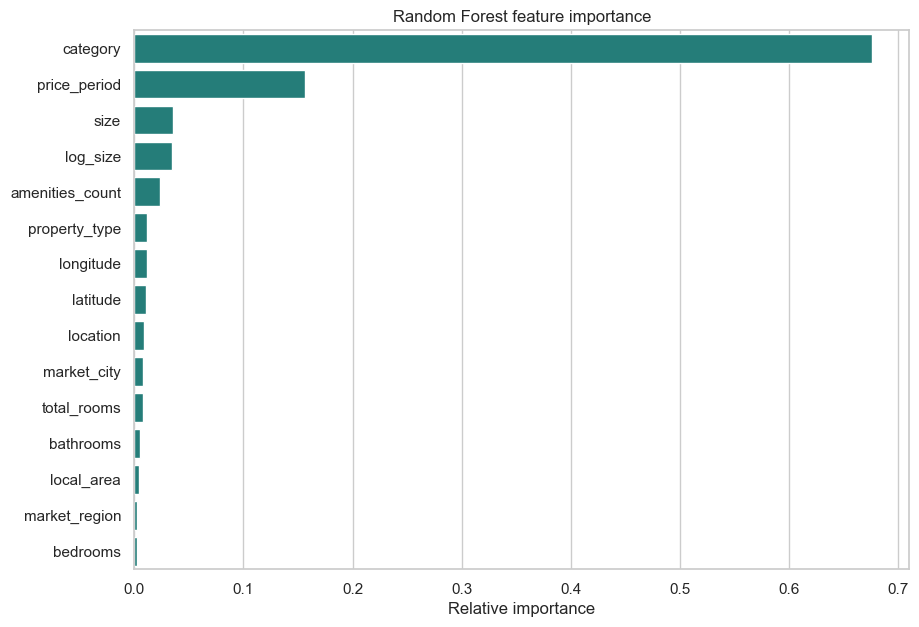

In [ ]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest_model
        .named_steps["model"]
        .feature_importances_,
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False,
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature",
    color="#168C86",
)
plt.title("Random Forest feature importance")
plt.xlabel("Relative importance")
plt.ylabel("")
plt.show()

### What should we conclude?

Market category, location, property type, and property scale should carry much of the signal. Importance can reveal whether an engineered feature helped, but it cannot tell us that changing that feature would cause the price to change.

## 15. Choose and Refit the Final Model

### Why retrain after model selection?

The holdout test set helped us choose Random Forest. Once that decision is finished, we can clone and refit the full preprocessing-plus-model pipeline on all cleaned rows so the deployed model learns from the complete modeling population.

### Can we free memory before the final refit?

The test predictions and metrics are already saved. We can remove unused fitted candidate objects before fitting the final model on all rows.

In [ ]:
import gc

del ridge_model, hist_gradient_model, xgboost_model
del hist_gradient_regressor, xgboost_regressor

gc.collect()

final_model = clone(random_forest_model)
final_model.set_params(model__n_jobs=1)

started = time.time()
final_model.fit(X, np.log1p(y_price))
final_training_seconds = time.time() - started

print(
    f"Final model trained on {len(X):,} rows "
    f"in {final_training_seconds:,.1f} seconds."
)

Final model trained on 62,494 rows in 21.4 seconds.


### What should we conclude?

This final model is for deployment and should not be evaluated on the same rows as if they were unseen. Our honest performance evidence remains the earlier holdout results.

## 16. Save a Complete Model Bundle

### Is saving only the fitted model enough?

The app also needs the exact feature order, category options, location coordinates, segment benchmarks, and error information. We will save them together as one versioned bundle.

In [ ]:
models_dir = Path("models")
artifacts_dir = Path("artifacts")

models_dir.mkdir(exist_ok=True)
artifacts_dir.mkdir(exist_ok=True)

location_groups = [
    "location",
    "market_region",
    "market_city",
    "local_area",
]

location_reference = modeling_df.groupby(
    location_groups,
    as_index=False,
).agg(
    latitude=("latitude", "median"),
    longitude=("longitude", "median"),
    listing_count=("price", "size"),
    median_price=("price", "median"),
)

location_reference = location_reference.sort_values(
    ["market_region", "market_city", "listing_count"],
    ascending=[True, True, False],
)

Regions and cities are alphabetical; common locations appear first inside each city.

Which property types belong to each market category?

In [ ]:
property_types_by_category = {}

for category_name, group in modeling_df.groupby("category"):
    property_types = group["property_type"].dropna().unique()
    property_types_by_category[category_name] = sorted(property_types)

category_price_summary = modeling_df.groupby("category")["price"].agg(
    listing_count="size",
    q25=lambda values: values.quantile(0.25),
    median="median",
    q75=lambda values: values.quantile(0.75),
)

final_segment_results = (
    segment_results[
        segment_results["model"].eq("Random Forest")
    ]
    .set_index("category")
)

category_summary = category_price_summary.join(
    final_segment_results[
        ["MAE", "RMSE", "R2", "median_APE"]
    ]
).to_dict(orient="index")

Each market category now has price context and observed test performance.

What must travel with the fitted model?

In [ ]:
model_bundle = {
    "model": final_model,
    "model_name": "RandomForestRegressor",
    "model_version": "session2-random-forest-v2",
    "target_transform": "log1p",
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "property_types_by_category": property_types_by_category,
    "location_reference": location_reference,
    "category_summary": category_summary,
    "feature_importance": feature_importance,
    "holdout_model_results": model_results_df,
    "cleaning_log": cleaning_log,
    "training_rows": len(modeling_df),
    "data_source": "Property Finder Egypt all_egypt.csv",
    "location_semantics": "marketplace breadcrumb, not official administrative boundaries",
}

bundle_path = models_dir / "property_price_model_bundle.joblib"
pipeline_path = models_dir / "property_price_random_forest_pipeline.joblib"
catboost_path = models_dir / "candidate_catboost.cbm"

joblib.dump(model_bundle, bundle_path, compress=3)
joblib.dump(final_model, pipeline_path, compress=3)
catboost_model.save_model(catboost_path)

We saved the deployed bundle, a standalone pipeline, and the comparison CatBoost candidate.

Which cleaned rows should be preserved for audit later?

In [ ]:
modeling_export_columns = ["id"] + feature_columns + ["price"]

modeling_df[modeling_export_columns].to_csv(
    artifacts_dir / "session2_modeling_data.csv",
    index=False,
)

model_card = {
    "model_name": model_bundle["model_name"],
    "model_version": model_bundle["model_version"],
    "training_rows": model_bundle["training_rows"],
    "target": "asking price in EGP",
    "target_transform": model_bundle["target_transform"],
    "segments": sorted(modeling_df["category"].unique()),
    "features": feature_columns,
    "important_limitations": [
        "Asking prices are not completed transaction prices.",
        "Monthly rent and sale prices are different targets.",
        "Location levels are marketplace labels, not official boundaries.",
        "The app range is not a confidence interval.",
        "Important property details are still missing.",
    ],
}

model_card_path = artifacts_dir / "model_card.json"

with open(model_card_path, "w", encoding="utf-8") as file:
    json.dump(model_card, file, indent=2, ensure_ascii=False)

print(f"Saved bundle: {bundle_path.resolve()}")
print(f"Bundle size: {bundle_path.stat().st_size / 1_000_000:,.1f} MB")

Saved bundle: Session_2_Project\models\property_price_model_bundle.joblib
Bundle size: 51.4 MB


### What should we conclude?

We saved four useful artifacts:

- a complete Joblib bundle for both apps;
- a standalone Random Forest pipeline and the candidate CatBoost `.cbm` model;
- the cleaned modeling table;
- a human-readable model card.

This is what turns an experiment into a reusable project.

## 17. Final Sanity Check

### Can the saved bundle make a prediction after reloading?

Reloading catches missing metadata, wrong paths, and serialization problems before we open Streamlit.

In [ ]:
loaded_bundle = joblib.load(bundle_path)

sample_input = X_test.iloc[[0]][
    loaded_bundle["feature_columns"]
]

sample_prediction_log = loaded_bundle["model"].predict(sample_input)[0]
sample_prediction = np.expm1(sample_prediction_log)

sanity_check = pd.DataFrame({
    "category": sample_input["category"].values,
    "property_type": sample_input["property_type"].values,
    "actual_price": [y_test_price.iloc[0]],
    "reloaded_model_prediction": [sample_prediction],
})

sanity_check.style.format({
    "actual_price": "{:,.0f} EGP",
    "reloaded_model_prediction": "{:,.0f} EGP",
})

,category,property_type,actual_price,reloaded_model_prediction
0,buy,Apartment,"1,000,000 EGP","1,259,995 EGP"


### What should we conclude?

The reloaded model predicts successfully using the exact saved feature contract. The model artifact is ready for `app.py` and `app2.py`.

## 18. Deployment Handoff

### How do we run the applications?

From a terminal opened inside `Session_2_Project`, run one of these commands:

```bash
streamlit run app.py
```

or

```bash
streamlit run app2.py
```

`app.py` teaches the minimum deployment pattern. `app2.py` adds cascading location controls, market context, an error-based range, plots, model transparency, and polished design.

## 19. Responsible Use

### What must we tell users before they trust the number?

This model predicts **advertised asking price**, not a bank valuation or completed transaction price. It can inherit market bias, scraping errors, and missing context. A user should compare the result with recent comparable listings and expert judgment.

For rent categories, the output means estimated monthly asking rent. For buy categories, it means estimated sale asking price.

## 20. Session 2 Ending

### What did we learn beyond “train a better model”?

We finished a real end-to-end workflow:

- defined the unit of analysis;
- kept all relevant property segments while separating project summaries;
- cleaned only with evidence;
- engineered deployable features;
- used pipelines to prevent inconsistent preprocessing;
- compared six models;
- evaluated each market separately;
- analyzed errors and limitations;
- retrained and saved a final model;
- connected the model to two applications.

The strongest Data Science lesson is this: **a model is not finished when `.fit()` succeeds. It is finished when the problem, evidence, evaluation, artifact, interface, and limitations all agree.**